In [4]:
from functools import partial
from pathlib import Path

import colormaps
import dask.array as darr
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import xarray as xr
from dask.array.lib.stride_tricks import sliding_window_view
from jetutils.data import extract, open_da, standardize, standardize_polars_dtypes
from jetutils.definitions import (
    DATADIR,
    FIGURES,
    MONTH_NAMES,
    N_WORKERS,
    RADIUS,
    RESULTS,
    YEARS,
    KAPPA,
    C_P_AIR,
    OMEGA,
    PRETTIER_VARNAME,
    UNITS,
    Timer,
    compute,
    do_rle,
    degcos,
    degsin,
    explode_rle,
    get_index_columns,
    get_region,
    polars_to_xarray,
    squarify,
    xarray_to_polars,
    iterate_over_year_maybe_member,

)
from jetutils.derived_quantities import (
    compute_2d_div,
    compute_norm_derivative,
    convolve_dask,
    find_axis,
)
from jetutils.geospatial import (
    compute_alignment,
    create_bias_correction,
    create_jet_relative_dataset,
    detect_contours,
    detect_contours_lonlat,
    diff_exp,
    gather_normal_da_jets,
    haversine,
    interp_jets_to_zero_one,
    sort_by_index_then_difflon,
    sort_by_index_then_newindex,
)
from jetutils.jet_finding import (
    average_jet_categories,
    bias_correct,
    coarsen_da,
    connected_from_cross,
    do_everything,
    extract_features,
    gaussian_smooth_func,
    has_periodic_x,
    jet_integral_haversine,
    jet_position_as_da,
    persistence_expr,
    preprocess_ds,
    round_polars,
    to_one_large,
    track_jets,
    compute_widths,
    find_all_jets,
    pers_from_cross,
    is_polar_gmix,
    compute_jet_props
)
from jetutils.plots import (
    COLORS,
    COLORS_EXT,
    Clusterplot,
    make_transparent,
    num2tex,
    plot_dayofyear_trends,
    plot_seasonal,
)
from matplotlib.cm import ScalarMappable
from matplotlib.colors import (
    BoundaryNorm,
    LinearSegmentedColormap,
    hsv_to_rgb,
    rgb_to_hsv,
)
from matplotlib.ticker import MaxNLocator
from polars.exceptions import ColumnNotFoundError
from scipy.interpolate import splev, splprep
from scipy.ndimage import gaussian_filter
from scipy.signal.windows import lanczos
from tqdm import tqdm, trange

%load_ext IPython.extensions.autoreload
%autoreload 2
%matplotlib inline

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


# new jets

In [ ]:
kwargs = dict(
    n_coarsen=1,
    base_s_thresh=0.55,
    alignment_thresh=0.6,
    int_thresh_factor=0.6,
    hole_size=6,
    smooth_func=partial(gaussian_smooth_func, sigma_lon=2, sigma_lat=0.8),
)

for exp in ["ctrl", "dobl"]:
    path = Path(DATADIR, "Henrik_data", exp, "high_wind/6H/results/2")
    ds = xr.open_dataset(path.joinpath("../1/da.nc"))
    ds = standardize(ds)
    ds = extract(
        ds, minlon=-80, maxlon=40, minlat=15, maxlat=80
    )
    theta300 = open_da("Henrik_data", exp, ("high_wind", ["s", "theta"]), "6H", minlon=-80, maxlon=40, minlat=15, maxlat=80, levels=30000).rename({"s": "s300", "theta": "theta300"})
    ds = xr.merge([ds, theta300])
    jets, ph_jets, props, props_full = do_everything(ds, path, feature_names=("s300", "theta300"), **kwargs)

 62%|██████▏   | 33/53 [08:55<05:31, 16.60s/it]

In [18]:
find_all_jets(xr.merge([ds, theta300]).sel(time=ds.time.dt.year==1969), **kwargs)

time,jet ID,index,lon,lat,side,u,v,s,theta,s300,theta300,sigma,s_thresh,int_thresh,alignment,literal,diff,len,int
datetime[ms],u32,i32,f32,f32,u32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32,f32
1969-01-01 00:00:00,0,0,-35.0,16.492147,0,25.900352,15.741252,30.308666,339.783752,25.403721,334.023621,-0.000007,24.879774,1.40847424e8,0.896817,10.0,10.0,60,3.13154336e8
1969-01-01 00:00:00,0,1,-33.75,17.434555,0,22.728243,16.07132,27.836313,339.386963,25.023434,333.797211,-0.000012,24.879774,1.40847424e8,0.998591,2.192408,2.192408,60,3.13154336e8
1969-01-01 00:00:00,0,2,-32.5,18.376963,0,21.96567,17.710478,28.216158,339.190796,27.15266,333.53772,-0.000008,24.879774,1.40847424e8,0.999984,2.192408,2.192408,60,3.13154336e8
1969-01-01 00:00:00,0,3,-31.25,19.319372,0,23.478741,17.722599,29.416693,339.209412,28.949919,333.736237,-0.000003,24.879774,1.40847424e8,0.999633,2.19241,2.19241,60,3.13154336e8
1969-01-01 00:00:00,0,4,-30.0,20.26178,0,24.805876,15.651403,29.330835,339.312592,29.54834,333.904144,-0.000001,24.879774,1.40847424e8,0.993509,2.192408,2.192408,60,3.13154336e8
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1969-12-31 18:00:00,3,60,-17.5,36.282722,0,-22.5963,8.078253,23.996895,331.53363,13.722414,327.086945,-0.000024,22.984756,1.30119496e8,0.941641,1.25,1.25,67,3.91253696e8
1969-12-31 18:00:00,3,61,-18.75,36.282722,0,-23.505993,12.782974,26.756983,331.682495,17.810577,326.729309,-0.000023,22.984756,1.30119496e8,0.878505,1.25,1.25,67,3.91253696e8
1969-12-31 18:00:00,3,62,-20.0,36.282722,0,-24.05986,16.233231,29.024036,331.793365,21.494574,326.222839,-0.000016,22.984756,1.30119496e8,0.987849,1.25,1.25,67,3.91253696e8


In [13]:
theta300

<xarray.Dataset> Size: 4GB
Dimensions:   (time: 75627, lat: 69, lon: 97)
Coordinates:
  * time      (time) datetime64[ms] 605kB 1969-01-01 ... 2021-01-03T12:00:00
  * lat       (lat) float32 276B 15.55 16.49 17.43 18.38 ... 77.75 78.69 79.63
  * lon       (lon) float32 388B -80.0 -78.75 -77.5 -76.25 ... 37.5 38.75 40.0
Data variables:
    s300      (time, lat, lon) float32 2GB dask.array<chunksize=(1111, 54, 97), meta=np.ndarray>
    theta300  (time, lat, lon) float32 2GB dask.array<chunksize=(1111, 54, 97), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              f.e20.F2000Nuopc.f09_f09_mg17.ctrl
    logname:           auestad
    host:              ln03
    initial_file:      /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    topography_file:   /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_6
    orig_lev:          [30000]

In [9]:
theta300 = open_da("Henrik_data", exp, ("high_wind", ["s", "theta"]), "6H", minlon=-80, maxlon=40, minlat=15, maxlat=80, levels=30000).rename({"s": "s300", "theta": "theta300"})

In [11]:
theta300

<xarray.Dataset> Size: 4GB
Dimensions:   (time: 75616, lat: 69, lon: 97)
Coordinates:
  * time      (time) datetime64[ms] 605kB 1969-01-01 ... 2020-12-31T18:00:00
  * lat       (lat) float32 276B 15.55 16.49 17.43 18.38 ... 77.75 78.69 79.63
  * lon       (lon) float32 388B -80.0 -78.75 -77.5 -76.25 ... 37.5 38.75 40.0
Data variables:
    s300      (time, lat, lon) float32 2GB dask.array<chunksize=(1111, 54, 97), meta=np.ndarray>
    theta300  (time, lat, lon) float32 2GB dask.array<chunksize=(1111, 54, 97), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              f.e20.F2000Nuopc.f09_f09_mg17.dobl
    logname:           auestad
    host:              ln04
    initial_file:      /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    topography_file:   /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_6
    orig_lev:          [30000]

In [10]:
theta300

<xarray.Dataset> Size: 4GB
Dimensions:   (time: 75616, lat: 69, lon: 97)
Coordinates:
  * time      (time) datetime64[ms] 605kB 1969-01-01 ... 2020-12-31T18:00:00
  * lat       (lat) float32 276B 15.55 16.49 17.43 18.38 ... 77.75 78.69 79.63
  * lon       (lon) float32 388B -80.0 -78.75 -77.5 -76.25 ... 37.5 38.75 40.0
Data variables:
    s300      (time, lat, lon) float32 2GB dask.array<chunksize=(1111, 54, 97), meta=np.ndarray>
    theta300  (time, lat, lon) float32 2GB dask.array<chunksize=(1111, 54, 97), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              f.e20.F2000Nuopc.f09_f09_mg17.dobl
    logname:           auestad
    host:              ln04
    initial_file:      /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    topography_file:   /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_6
    orig_lev:          [30000]

In [8]:
jets

time,jet ID,index,lon,lat,side,u,v,s,theta,sigma,s_thresh,int_thresh,alignment,literal,diff,len,int,is_polar
datetime[ms],u32,i32,f32,f32,u32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32,f32,f64
1969-01-01 00:00:00,0,0,-35.0,16.492147,0,25.900352,15.741252,30.308666,339.783936,-0.000007,24.879774,1.40847424e8,0.896817,10.0,10.0,60,3.13154336e8,0.410598
1969-01-01 00:00:00,0,1,-33.75,17.434555,0,22.728243,16.07132,27.836313,339.386108,-0.000012,24.879774,1.40847424e8,0.998591,2.192408,2.192408,60,3.13154336e8,0.446794
1969-01-01 00:00:00,0,2,-32.5,18.376963,0,21.96567,17.710478,28.216158,339.190002,-0.000008,24.879774,1.40847424e8,0.999984,2.192408,2.192408,60,3.13154336e8,0.442428
1969-01-01 00:00:00,0,3,-31.25,19.319372,0,23.478741,17.722599,29.416693,339.209839,-0.000003,24.879774,1.40847424e8,0.999633,2.19241,2.19241,60,3.13154336e8,0.426041
1969-01-01 00:00:00,0,4,-30.0,20.26178,0,24.805876,15.651403,29.330835,339.312134,-0.000001,24.879774,1.40847424e8,0.993509,2.192408,2.192408,60,3.13154336e8,0.427096
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2020-12-31 18:00:00,0,82,12.5,50.41885,0,36.97002,-17.266838,40.803505,333.096191,-0.000003,25.022385,1.41654752e8,0.906061,1.25,1.25,89,4.84368736e8,0.538642
2020-12-31 18:00:00,0,83,13.75,50.41885,0,35.208263,-17.767298,39.437275,333.649353,0.000002,25.022385,1.41654752e8,0.997784,1.25,1.25,89,4.84368736e8,0.579268
2020-12-31 18:00:00,0,84,15.0,49.47644,0,31.364044,-20.228346,37.32143,332.706543,-0.000003,25.022385,1.41654752e8,0.99891,2.19241,2.19241,89,4.84368736e8,0.566942


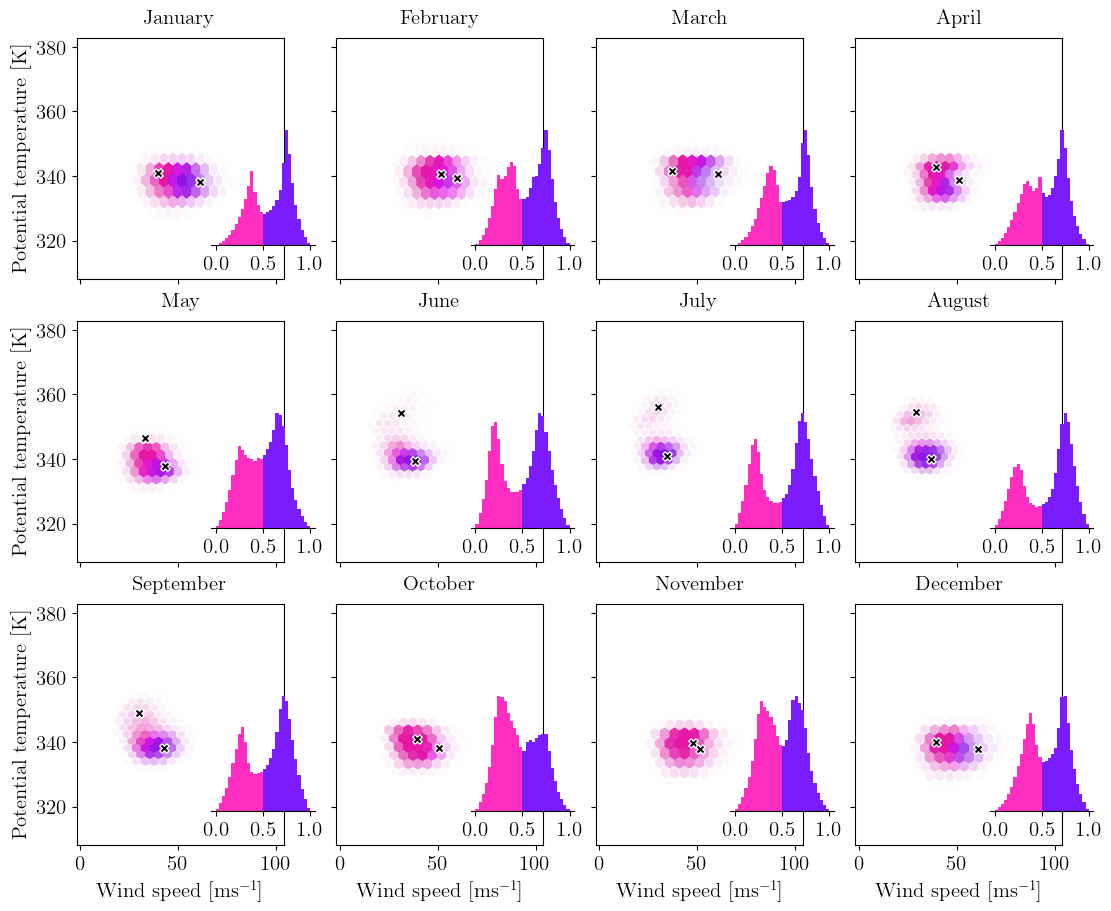

In [5]:
xys = []
# .filter(pl.col("int") > 1.1e8)

xys = np.array(xys)
fig, axes = plt.subplots(
    3, 4, figsize=(11, 9), constrained_layout=True, sharex="all", sharey="all"
)
axes = axes.ravel()
pair = ["s", "theta", "is_polar"]
cmap = LinearSegmentedColormap.from_list(
    "pinkredpurple", [COLORS[2], COLORS_EXT[8], COLORS[1]]
)
bins = np.linspace(0, 1, 31)
gridsize = 18
for month in range(1, 13):
    ax = axes[month - 1]
    X = extract_features(jets, pair, season=month)
    probas = X[pair[2]]
    center_stj = X.filter(pl.col("is_polar") < 0.3).mean()
    center_edj = X.filter(pl.col("is_polar") > 0.7).mean()
    X1D = X["is_polar"]

    im1 = ax.hexbin(X[pair[0]], X[pair[1]], cmap=colormaps.gray_r, gridsize=gridsize)
    im2 = ax.hexbin(
        X[pair[0]], X[pair[1]], C=probas, cmap=colormaps.gray_r, gridsize=gridsize
    )

    plt.draw()

    offsets1 = np.asarray(list(map(tuple, im1.get_offsets())), dtype="f, f")
    offsets2 = np.asarray(list(map(tuple, im2.get_offsets())), dtype="f, f")
    mask12 = np.isin(offsets1, offsets2)
    colors = cmap(im2.get_array())
    colors = rgb_to_hsv(colors[:, :3])
    min_s, max_s = 0.0, 0.9
    min_v, max_v = 0.9, 1.0
    scaling = np.clip(
        im1.get_array()[mask12] / im1.get_array()[mask12].max() * 1.1, 0, 1
    )
    f = lambda x: np.pow(x, 2)
    colors[:, 1] = min_s + f(scaling ** 1.5) * (max_s - min_s)
    colors[:, 2] = max_v - f(scaling) * (max_v - min_v)
    colors = hsv_to_rgb(colors)
    im2.set_array(None)
    im2.set_facecolor(colors)
    # im2.set_linewidths(0.2)
    im2.set_linewidths(np.clip(2 - 3 * (scaling), 0, 2))
    im2.set_edgecolor("white")
    im2 = ax.add_collection(im2)
    if month > 8:
        label = PRETTIER_VARNAME.get(pair[0], pair[0])
        unit = UNITS.get(pair[0], "$~$")
        ax.set_xlabel(f"{label} [{unit}]")
    if month % 4 == 1:
        label = PRETTIER_VARNAME.get(pair[1], pair[1])
        unit = UNITS.get(pair[1], "$~$")
        ax.set_ylabel(f"{label} [{unit}]")
    if pair[0] in ["lev", "theta"]:
        ax.invert_xaxis()
    elif pair[1] in ["lev", "theta"]:
        ax.invert_yaxis()

    ax.set_title(MONTH_NAMES[month - 1])
    ax.scatter(
        *pl.concat([center_stj, center_edj])[pair[:2]].to_numpy().T,
        facecolor="black",
        edgecolor="white",
        marker="X",
        linewidths=1,
        s=45,
    )
    iax = ax.inset_axes([0.65, 0.14, 0.5, 0.5])
    X1D = np.clip(X1D, 0, 1)
    iax.hist(X1D, bins=bins, alpha=0.5, color="black")
    iax.hist(X1D[probas > 0.5], bins=bins, alpha=1.0, color=COLORS[1])
    iax.hist(X1D[probas < 0.5], bins=bins, alpha=1.0, color=COLORS[2])
    iax.set_xticks([0, 0.5, 1])
    iax.set_yticks([])
    iax.spines[["left", "right", "top"]].set_visible(False)
    iax.set_facecolor((1.0, 1.0, 1.0, 0.0))
    plt.draw()
    # break
# fig.savefig(f"{FIGURES}/FeatureBased/gmix_demo.pdf")

# Eddy stuff for everyone

## ERA5

In [9]:
import warnings
uv_sample = []
basepath = Path(DATADIR, "ERA5/plev/uv/6H")
if not basepath.joinpath("full250.zarr").is_dir():
    for i, f in enumerate(tqdm(list(basepath.glob("*.nc")))):
        uv_sample = xr.open_dataset(f)
        uv_sample = standardize(uv_sample).sel(lev=[300, 250]).chunk({"lev": -1})
        uv_sample["theta"] = uv_sample["t"] * (1000 / uv_sample["lev"]) ** KAPPA
        uv_sample = uv_sample.drop_vars("t")
        for var in ["u", "v", "theta"]:
            uv_sample[f"d{var}dp"] = uv_sample[var].differentiate("lev")
        uv_sample = uv_sample.sel(lev=250)
        kwargs = {"mode": "w"} if i == 0 else {"mode": "a", "append_dim": "time"}
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            uv_sample.to_zarr(basepath.joinpath("full250.zarr"), align_chunks=True, **kwargs)

In [ ]:
ds = xr.open_zarr(basepath.joinpath("full250.zarr")).sel(lat=slice(15, 85), lon=slice(-80, 40)).sortby("time")

half_len = 20
l_win = lanczos(2 * half_len + 1)[:, None, None]
dims = ds.dims
for var in ["u", "v", "w", "theta"]:
    ds[f"{var}bar"] = (
        dims,
        (convolve_dask(ds[var].data, l_win)[half_len:-half_len] / l_win.sum()).astype(
            np.float32
        ),
    )
    ds[f"{var}p"] = ds[var] - ds[f"{var}bar"]
    del ds[f"{var}bar"]
    del ds[var]
    
gamma = (-KAPPA / ds.lev * (1000 / ds.lev) ** KAPPA * ds["dthetadp"].mean(["time", "lon", "lat"])).astype(np.float32)
EAPE = (C_P_AIR * 0.5 * (ds.lev * 1e-5) ** (2 * KAPPA) * gamma * ds["thetap"] ** 2).astype(np.float32)
S = (0.5 * (ds["up"] ** 2 + ds["vp"] ** 2 - EAPE)).astype(np.float32)
EKE = 0.5 * (ds["up"] ** 2 + ds["vp"] ** 2)
EKE = EKE.astype(np.float32)
f = (2 * OMEGA * degsin(ds.lat)).astype(np.float32)

## Base 2 * 3
ds["EKE"] = EKE
ds["F11"] = ds["up"] ** 2 - EKE
ds["F12"] = ds["up"] * ds["vp"]
ds["F13"] = - ds["vp"] * ds["thetap"] * f / ds["dthetadp"]
# ds["F21"] = ds["up"] * ds["vp"]
ds["F22"] = ds["vp"] ** 2 - EKE
ds["F23"] = ds["up"] * ds["thetap"] * f / ds["dthetadp"]

## Additional from original EP:
ds["F12_extra"] = - ds["dudp"] * ds["vp"] * ds["thetap"] / ds["dthetadp"]
ds["F13_extra"] = ds["up"] * ds["wp"]
ds["F23_extra"] = ds["vp"] * ds["wp"]

for f in ds.data_vars:
    if f[0] == "F":
        ds[f] = ds[f] * RADIUS * degcos(ds.lat)
ds["hor1"] = compute_2d_div(ds, "F11", "F12")
ds["hor2"] = compute_2d_div(ds, "F12", "F22")
ds = ds.drop_vars(["dthetadp", "dudp", "dvdp"])

In [30]:
ds

<xarray.Dataset> Size: 170GB
Dimensions:    (lat: 141, lon: 241, time: 96428)
Coordinates:
  * lat        (lat) float32 564B 15.0 15.5 16.0 16.5 ... 83.5 84.0 84.5 85.0
  * lon        (lon) float32 964B -80.0 -79.5 -79.0 -78.5 ... 39.0 39.5 40.0
  * time       (time) datetime64[ns] 771kB 1959-01-01 ... 2024-12-31T18:00:00
    lev        float32 4B ...
Data variables: (12/13)
    up         (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
    vp         (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
    wp         (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
    thetap     (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
    EKE        (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
    F11        (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
    ...         ...
    F13        (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
    F22        (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
    F23        (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
    F12_extra  (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
    F13_extra  (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
    F23_extra  (time, lat, lon) float32 13GB dask.array<chunksize=(61, 61, 121), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-15T20:16 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
ds.to_zarr(basepath.joinpath("results/.zarr"), align_chunks=True)

<xarray.Dataset> Size: 157GB
Dimensions:   (time: 96428, lat: 181, lon: 321)
Coordinates:
  * time      (time) datetime64[ns] 771kB 1959-01-01 ... 2024-12-31T18:00:00
  * lat       (lat) float32 724B 0.0 0.5 1.0 1.5 2.0 ... 88.5 89.0 89.5 90.0
  * lon       (lon) float32 1kB -100.0 -99.5 -99.0 -98.5 ... 58.5 59.0 59.5 60.0
    lev       float32 4B ...
Data variables:
    dthetadp  (time, lat, lon) float32 22GB dask.array<chunksize=(61, 91, 161), meta=np.ndarray>
    dudp      (time, lat, lon) float32 22GB dask.array<chunksize=(61, 91, 161), meta=np.ndarray>
    dvdp      (time, lat, lon) float32 22GB dask.array<chunksize=(61, 91, 161), meta=np.ndarray>
    up        (time, lat, lon) float32 22GB dask.array<chunksize=(61, 91, 161), meta=np.ndarray>
    vp        (time, lat, lon) float32 22GB dask.array<chunksize=(61, 91, 161), meta=np.ndarray>
    wp        (time, lat, lon) float32 22GB dask.array<chunksize=(61, 91, 161), meta=np.ndarray>
    thetap    (time, lat, lon) float32 22GB dask.array<chunksize=(61, 91, 161), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-15T20:16 GRIB to CDM+CF via cfgrib-0.9.1...

## Henrik stuff

In [ ]:
xr.open_dataset("/storage/workspaces/giub_meteo_impacts/ci01/Henrik_data/ctrl/high_wind/6H/1969.nc")

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 1460, lat: 96, lon: 288, lev: 2)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1969-01-01 ... 1969-12-31T18:00:00
  * lat      (lat) float32 384B 0.4712 1.414 2.356 3.298 ... 88.12 89.06 90.0
  * lon      (lon) float32 1kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
  * lev      (lev) int32 8B 20000 30000
Data variables:
    u        (time, lat, lon, lev) float32 323MB ...
    v        (time, lat, lon, lev) float32 323MB ...
    t        (time, lat, lon, lev) float32 323MB ...
    DTCOND   (time, lat, lon, lev) float32 323MB ...
    PTTEND   (time, lat, lon, lev) float32 323MB ...
    s        (time, lat, lon, lev) float32 323MB ...
    theta    (time, lat, lon, lev) float64 646MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              f.e20.F2000Nuopc.f09_f09_mg17.ctrl
    logname:           auestad
    host:              ln03
    initial_file:      /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    topography_file:   /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_6

In [25]:
xr.open_dataset("/storage/workspaces/giub_meteo_impacts/ci01/Henrik_data/ctrl/vertical/6H/1969.nc")

<xarray.Dataset> Size: 3GB
Dimensions:   (time: 1460, lat: 192, lon: 288, lev: 2)
Coordinates:
  * time      (time) datetime64[ns] 12kB 1969-01-01 ... 1969-12-31T18:00:00
  * lat       (lat) float32 768B -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon       (lon) float32 1kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
  * lev       (lev) int32 8B 20000 30000
Data variables:
    dudp      (time, lat, lon, lev) float32 646MB ...
    dvdp      (time, lat, lon, lev) float32 646MB ...
    dthetadp  (lev, time, lat, lon) float64 1GB ...
    omega     (time, lat, lon, lev) float32 646MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              f.e20.F2000Nuopc.f09_f09_mg17.ctrl
    logname:           auestad
    host:              ln03
    initial_file:      /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    topography_file:   /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_6

In [12]:
eddy_era5 = xr.open_dataset("/storage/workspaces/giub_meteo_impacts/ci01/ERA5/plev/eddy_stuff/6H/full.zarr")

In [13]:
eddy_era5

<xarray.Dataset> Size: 130GB
Dimensions:  (time: 93504, lat: 181, lon: 321)
Coordinates:
  * time     (time) datetime64[ns] 748kB 1959-01-01 ... 2022-12-31T18:00:00
  * lat      (lat) float32 724B 0.0 0.5 1.0 1.5 2.0 ... 88.0 88.5 89.0 89.5 90.0
  * lon      (lon) float32 1kB -100.0 -99.5 -99.0 -98.5 ... 58.5 59.0 59.5 60.0
    lev      float32 4B ...
Data variables:
    EKE      (time, lat, lon) float32 22GB ...
    F11      (time, lat, lon) float32 22GB ...
    F12      (time, lat, lon) float32 22GB ...
    F22      (time, lat, lon) float32 22GB ...
    hor1     (time, lat, lon) float32 22GB ...
    hor2     (time, lat, lon) float32 22GB ...

In [10]:
eddy_henrik = xr.open_zarr("/storage/workspaces/giub_meteo_impacts/ci01/Henrik_data/ctrl/high_wind/6H/results/F.zarr")

/scratch/local/5165880/ipykernel_793083/325929436.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  eddy_henrik = xr.open_zarr("/storage/workspaces/giub_meteo_impacts/ci01/Henrik_data/ctrl/high_wind/6H/results/F.zarr")


In [11]:
eddy_henrik

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              f.e20.F2000Nuopc.f09_f09_mg17.ctrl
    logname:           auestad
    host:              ln03
    initial_file:      /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    topography_file:   /work/n02/n02/auestad/cesm/CESM2.1.3/cesm_inputdata/at...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_6

In [ ]:
# RUN THIS NEXT TIME:
import polars.selectors as cs
for run in ["ctrl", "dobl", "ctrl_p4"]:
    fs = list(Path(DATADIR).glob(f"Henrik_data/{run}/high_wind/6H/results/1/*_relative.parquet"))
    for f in tqdm(fs):
        df = pl.read_parquet(f)
        df = df.with_columns(cs.float().cast(pl.Float32()))
        df = df.with_columns(cs.signed_integer().cast(pl.Int32()))
        df = df.with_columns(cs.unsigned_integer().cast(pl.UInt32()))
        df = df.with_columns(cs.datetime().cast(pl.Datetime("ms")))
        df.write_parquet(f)

# unrolled scripts

In [ ]:
import os
from pathlib import Path
from itertools import product

import dask.array as darr
import numpy as np
import polars as pl
import xarray as xr
from jetutils.data import open_da, smooth
from jetutils.definitions import (
    DATADIR,
    YEARS,
    compute,
    N_WORKERS,
    DEFAULT_VARNAME,
    degsin,
    OMEGA,
    C_P_AIR,
    KAPPA,
)
from jetutils.derived_quantities import compute_absolute_vorticity, compute_2d_conv
from jetutils.geospatial import (
    gather_normal_da_jets,
    interp_jets_to_zero_one,
    detect_contours_lonlat,
    detect_overturnings,
    event_props,
    to_xarray_sjoin,
    detect_streamers,
)
from jetutils.jet_finding import (
    DataHandler,
    JetFindingExperiment,
    add_feature_for_cat,
    iterate_over_year_maybe_member,
)
from scipy.signal.windows import lanczos
from tqdm import tqdm, trange

os.environ["RUST_BACKTRACE"] = "full"


def convolve(in1, in2, mode="full", method="fft", axes=None):
    from scipy.signal import fftconvolve, oaconvolve
    from scipy.signal._signaltools import _init_freq_conv_axes

    in1 = darr.asarray(in1)
    in2 = np.asarray(in2)

    # Checking for trivial cases and incorrect flags
    if in1.ndim == in2.ndim == 0:  # scalar inputs
        return in1 * in2
    elif in1.ndim != in2.ndim:
        raise ValueError("in1 and in2 should have the same dimensionality")
    elif in1.size == 0 or in2.size == 0:  # empty arrays
        return np.array([])

    if mode != "full" and mode != "same" and mode != "valid" and mode != "periodic":
        raise ValueError(
            "acceptable mode flags are 'valid', 'same', 'full' or 'periodic'"
        )
    if method not in ["fft", "oa"]:
        raise ValueError("acceptable method flags are 'oa', or 'fft'")

    # Pre-formatting or the the inputs, mainly for the `axes` argument
    in1, in2, axes = _init_freq_conv_axes(in1, in2, mode, axes, sorted_axes=False)

    # _init_freq_conv_axes calls a function that will swap out inputs if required
    # when mode == "valid".We want to avoid having in2 be a dask array thus check
    # to see if the inputs were swapped and raise an error.
    if isinstance(in1, np.ndarray):
        raise ValueError(
            "For 'valid' mode in1 has to be at least as large as in2 in every dimension"
        )

    s1 = in1.shape
    s2 = in2.shape

    # If all axe were removed by the preformatting we only have to rely
    # on multiplication broadcasting rules.
    if not len(axes):
        in_cv = in1 * in2
        # This is the "full" output that is also valid.
        # To get the "same" output we need to center in some dimensions.
        if mode == "same" or mode == "periodic":
            not_axes_but_s1_1 = [
                a
                for a in range(in1.ndim)
                if a not in axes and s1[a] == 1 and s2[a] != 1
            ]
            in_cv = in_cv[
                tuple(
                    (
                        slice((s2[a] - 1) // 2, (s2[a] - 1) // 2 + 1)
                        if a in not_axes_but_s1_1
                        else slice(None, None)
                    )
                    for a in range(in1.ndim)
                )
            ]
            return in_cv

    else:
        # This is kind of a hack but it works.
        not_axes_but_s1_1 = [
            a for a in range(in1.ndim) if a not in axes and s1[a] == 1 and s2[a] != 1
        ]
        if len(not_axes_but_s1_1) and (mode == "full" or mode == "valid"):
            new_shape = tuple(
                s1[i] for i in range(in1.ndim) if i not in not_axes_but_s1_1
            )
            in1 = in1.reshape(new_shape)
            for a in not_axes_but_s1_1:
                in1 = darr.stack([in1] * s2[a], axis=a)
            return convolve(in1, in2, mode=mode, method=method, axes=axes)

        # Deals with the case where there is at least one axis a in which we do not
        # do the convolution that has s2[a] == s1[a] != 1
        not_axes_but_same_shape = [
            a for a in range(in1.ndim) if a not in axes and s1[a] == s2[a] != 1
        ]
        if len(not_axes_but_same_shape):
            to_rechunk = [a for a in not_axes_but_same_shape if len(in1.chunks[a]) != 1]
            new_chunk_size = tuple(
                -1 if a in to_rechunk else "auto" for a in range(in1.ndim)
            )
            in1 = in1.rechunk(new_chunk_size)

        depth = {i: s2[i] // 2 for i in axes}

        # Flags even dimensions and removes them by adding zeros
        # This is done to avoid from having some results show up twice
        # at the edge of blocks
        even_flag = np.r_[[1 - s2[a] % 2 if a in axes else 0 for a in range(in1.ndim)]]
        target_shape = np.asarray(s2)
        target_shape += even_flag

        if any(target_shape != np.asarray(s2)):
            # padding axes where in2 is even
            pad_width = tuple(
                (even_flag[a], 0) if a in axes else (0, 0) for a in range(in1.ndim)
            )
            in2 = darr.pad(in2, pad_width)

        if mode != "valid":
            pad_width = tuple(
                (depth[i] - even_flag[i], depth[i]) if i in axes else (0, 0)
                for i in range(in1.ndim)
            )
            in1 = darr.pad(in1, pad_width)

        if mode == "periodic":
            boundary = "periodic"
        else:
            boundary = 0

        cv_dict = {"oa": oaconvolve, "fft": fftconvolve}

        def cv_func(x):
            return cv_dict[method](x, in2, mode="same", axes=axes)

        complex_result = in1.dtype.kind == "c" or in2.dtype.kind == "c"

        if complex_result:
            dtype = "complex"
        else:
            dtype = "float"

        # Actualy does the convolution with all the parameters preformatted
        in_cv = in1.map_overlap(
            cv_func, depth=depth, boundary=boundary, trim=True, dtype=dtype
        )

        # The output as to be reduced depending on the `mode` argument
        if mode == "valid":
            output_slicing = tuple(
                (
                    slice(depth[i], s1[i] - (depth[i] - even_flag[i]), 1)
                    if i in depth.keys()
                    else slice(0, None)
                )
                for i in range(in1.ndim)
            )
            in_cv = in_cv[output_slicing]

        elif mode != "full":
            # Only have to undo the padding
            output_slicing = tuple(
                slice(p[0], -p[1]) if p != (0, 0) else slice(0, None) for p in pad_width
            )
            in_cv = in_cv[output_slicing]

    return in_cv


def create_jet_relative_dataset(
    jets,
    da,
    bias_correction: pl.DataFrame | None = None,
    half_length: float = 2e6,
    dn: float = 1e5,
    n_interp: int = 30,
    in_meters: bool = True,
):
    indexer = list(iterate_over_year_maybe_member(jets, ds))
    to_average = []
    index_columns = get_index_columns(
        jets, 
        (
            "member",
            "time",
            "cluster",
            "spell",
            "relative_index",
            "relative_time",
            "sample_index",
            "inside_index"
        )
    )
    varname = da.name + "_interp"
    for idx1, idx2 in tqdm(indexer, total=len(indexer)):
        jets_ = jets.filter(*idx1)
        da_ = da.sel(**idx2)
        if bias_correction is not None:
            bias_correction_ = bias_correction.filter(*idx1)
            extra_n = bias_correction["n_max"].abs().max()
        else:
            bias_correction_ = None
            extra_n = 0
        try:
            jets_with_interp = gather_normal_da_jets(
                jets_,
                da_,
                half_length=half_length + extra_n,
                dn=dn,
                in_meters=in_meters,
            )
        except (KeyError, ValueError) as e:
            print(e)
            break
        if bias_correction_ is not None:
            jets_with_interp = (
                jets_with_interp
                .join(bias_correction_, on=[*index_columns, "jet ID", "index"])
                .with_columns(n=pl.col("n") - pl.col("n_max"))
                .filter(pl.col("n").abs() <= 2e6)
                .with_columns(side=pl.col("n").sign().cast(pl.Int32()))
                .drop("n_max")
            )
            jets_with_interp = jets_with_interp.filter(pl.col("n").abs() <= 2e6)
        jets_with_interp = interp_jets_to_zero_one(
            jets_with_interp, [varname, "is_polar"], n_interp=n_interp
        )
        to_average.append(jets_with_interp)
    return pl.concat(to_average)


def create_bias_correction(
    jets,
    ds,
    period: int = 15
):
    offset = int(np.ceil(period / 2))
    indexer = list(iterate_over_year_maybe_member(jets, ds))
    to_average = []
    index_columns = get_index_columns(
        jets, 
        (
            "member",
            "time",
            "cluster",
            "spell",
            "relative_index",
            "relative_time",
            "sample_index",
            "inside_index"
        )
    )
    for idx1, idx2 in tqdm(indexer, total=len(indexer)):
        jets_ = jets.filter(*idx1)
        ds_ = ds.sel(**idx2)
        sigma = compute_norm_derivative(ds_, "s").rename("sigma")
        interpd = gather_normal_da_jets(
            jets_, sigma, dn=1e5, half_length=4e5, in_meters=True
        )
        interpd = interp_jets_to_zero_one(
            interpd, ["sigma_interp", "is_polar"], n_interp=30
        )
        mapper = interpd["norm_index"].unique().sort().to_frame().with_row_index("indexer")
        bias_correction = (
            interpd[*index_columns, "jet ID", "norm_index", "n", "sigma_interp"]
            .join(mapper, on="norm_index")
            .rolling("indexer", period=f"{period}i", offset=f"-{offset}i", group_by=(*index_columns, "jet ID", "n"))
            .agg(pl.col("sigma_interp").mean())
            .join(mapper, on="indexer")
            .drop("indexer")
        )
        bias_correction = polars_to_xarray(bias_correction, ["time", "jet ID", "n", "norm_index"])
        bias_correction = detect_contours(bias_correction, [0.], ("norm_index", "n"))
        bias_correction = bias_correction.filter((pl.lit(0.).is_in(pl.col("norm_index").implode()) & pl.lit(1.).is_in(pl.col("norm_index").implode())).over("time", "jet ID", "contour"))
        bias_correction.drop("level", "cyclic").group_by("time", "jet ID", "norm_index").agg(pl.col("n").get(pl.col("n").abs().arg_min()))
        to_average.append(bias_correction)
    return pl.concat(to_average)

In [ ]:
# block 1: compute zeta
for run in ["ctrl", "dobl", "ctrl_p4"]:
    basepath_i = Path(DATADIR, f"Henrik_data/{run}/high_wind/6H")
    basepath_zeta = Path(DATADIR, f"Henrik_data/{run}/zeta/6H")
    basepath_zeta.mkdir(parents=True, exist_ok=True)

    glob = basepath_i.glob("????.nc")

    for f in glob:
        oname = f.name
        ofile = basepath_zeta.joinpath(oname)
        if not ofile.is_file():
            ds = xr.open_dataset(f)
            ds = ds[["u", "v"]]
            ds = ds.transpose("time", "lev", "lat", "lon")
            zeta = compute_absolute_vorticity(ds)
            zeta.to_netcdf(ofile)
            print("zeta", oname, run)

In [ ]:
# block 2: compute eddy stuff
for run in ["ctrl", "dobl", "ctrl_p4"]:
    opath = Path(
        f"{DATADIR}/Henrik_data/{run}/high_wind/6H/results",
        "Eddy_NH_10days.zarr",
    )
    if opath.is_dir():
        continue
    half_len = 20
    ds = (
        xr.open_mfdataset(
            f"{DATADIR}/Henrik_data/{run}/high_wind/6H/*.nc",
            combine="nested",
            concat_dim="time",
        )[["u", "v", "theta"]]
        .sel(lat=slice(0, 90))
        .chunk("auto")
    )
    for var in ds.data_vars:
        ds[var] = ds[var].astype(np.float32)
    huh = xr.open_mfdataset(
        f"{DATADIR}/Henrik_data/{run}/vertical/6H/*.nc",
        combine="nested",
        concat_dim="time",
    )
    try:
        huh = huh.rename({"OMEGA": "omega"})
    except (ValueError, KeyError):
        pass
    ds["omega"] = (
        huh["omega"]
        .astype(np.float32)
        .sel(lat=slice(0, 90))
        .chunk("auto")
    )
    l_win = lanczos(2 * half_len + 1)[:, None, None, None]
    dims = ds.dims
    for var in ds.data_vars:
        ds[f"{var}bar"] = (
            dims,
            (convolve(ds[var].data, l_win)[half_len:-half_len] / l_win.sum()).astype(
                np.float32
            ),
        )
        ds[f"{var}p"] = ds[var] - ds[f"{var}bar"]
        del ds[f"{var}bar"]
        del ds[var]
    ds = ds.chunk({"time": 1390, "lat": 72, "lon": 161})
    res = ds.to_zarr(opath, compute=False)
    compute(res, progress=True)

In [ ]:
# block 3: EP Flux
for run in ["ctrl", "dobl", "ctrl_p4"]:
    ipath = Path(
        f"{DATADIR}/Henrik_data/{run}/high_wind/6H/results",
        "Eddy_NH_10days.zarr",
    )
    odir = Path(f"{DATADIR}/Henrik_data/{run}/EPF/6H")
    odir.mkdir(parents=True, exist_ok=True)
    bigds = xr.open_dataset(ipath).sel(lev=[20000, 30000]).chunk("auto")
    for year in trange(1969, 2021):
        ofile = odir.joinpath(f"{year}.nc")
        if ofile.is_file():
            continue
        ds = bigds.sel(time=bigds.time.dt.year == year)
        other = xr.open_dataset(f"{DATADIR}/Henrik_data/{run}/vertical/6H/{year}.nc").sel(lat=slice(0, None))
        ds = xr.merge([ds, other])
        ds["u"] = xr.open_dataset(f"{DATADIR}/Henrik_data/{run}/high_wind/6H/{year}.nc")["u"].sel(lat=slice(0, None))
        
        gamma = (-KAPPA / ds.lev * (100000 / ds.lev) ** KAPPA * ds["dthetadp"].mean(["time", "lon", "lat"])).astype(np.float32)
        EAPE = (C_P_AIR * 0.5 * (ds.lev * 1e-5) ** (2 * KAPPA) * gamma * ds["thetap"] ** 2).astype(np.float32)
        S = (0.5 * (ds["up"] ** 2 + ds["vp"] ** 2 - EAPE)).astype(np.float32)
        f = (2 * OMEGA * degsin(ds.lat)).astype(np.float32)

        ## Base 2 * 3
        ds["F11"] = ds["up"] ** 2 - S
        ds["F12"] = ds["up"] * ds["vp"]
        ds["F13"] = - ds["vp"] * ds["thetap"] * f / ds["dthetadp"]
        ds["F21"] = ds["up"] * ds["vp"]
        ds["F22"] = ds["vp"] ** 2 - S
        ds["F23"] = ds["up"] * ds["thetap"] * f / ds["dthetadp"]

        ## Additional from original EP:
        ds["F12_extra"] = - ds["dudp"] * ds["vp"] * ds["thetap"] / ds["dthetadp"]
        ds["F13_extra"] = ds["up"] * ds["omegap"]
        ds["F23_extra"] = ds["vp"] * ds["omegap"]
        ds = ds.drop_vars([var for var in list(ds.data_vars) if var[0] != "F"])
        ds = compute(ds, progress_flag=False)
        ds.to_netcdf(ofile)

In [ ]:
# block 3.5: EP Flux convergence


In [ ]:
# block 4: WB
levels = compute(xr.open_mfdataset(list(Path(DATADIR, "Henrik_data/ctrl/zeta/6H").glob("*0.nc")))[DEFAULT_VARNAME].quantile([0.5]), progress_flag=True).values
levels = (levels * 1e5).round(1).tolist()
for run in ["ctrl", "dobl", "ctrl_p4"]:
    basepath_zeta = Path(DATADIR, f"Henrik_data/{run}/zeta/6H")
    da_mflux = xr.open_dataset(
        f"{DATADIR}/Henrik_data/{run}/high_wind/6H/results/Eddy_NH_10days.zarr"
    ).sel(lev=30000)
    da_mflux = (da_mflux["up"] * da_mflux["vp"]).rename("EMF")
    opath = Path(DATADIR, "Henrik_data", run) 
    opath_rwb = Path(DATADIR, f"Henrik_data/{run}/rwb_index")
    opath_rwb.mkdir(exist_ok=True)
    for year in trange(1969, 2021):
        ofile = opath_rwb.joinpath(f"overturnings_{year}.parquet")
        
        if opath.joinpath(f"CAVO/6H/{year}.nc").is_file() and ofile.is_file():
            continue
            
        zeta = xr.open_dataarray(basepath_zeta.joinpath(f"{year}.nc")).sel(lev=30000)
        zeta = zeta.rename("zeta") * 1e5
        for potential in ["lev", "loni", "lati"]:
            try:
                zeta = zeta.reset_coords(potential, drop=True)
            except ValueError:
                continue
        mflux = da_mflux.sel(time=zeta.time)
        mflux = mflux.rename("mflux").reset_coords("lev", drop=True)
        zeta = smooth(zeta, {"lon": ("win", 5), "lat": ("win", 5)})
        zeta = compute(zeta)
        # mflux = smooth(mflux, {"lon": ("win", 5), "lat": ("win", 5)})
        mflux = compute(mflux)
        if ofile.is_file():
            overturnings = pl.read_parquet(ofile)
            overturnings_on_grid = None
        else:
            contours = detect_contours_lonlat(zeta, levels, processes=N_WORKERS, ctx="fork")
            overturnings = detect_overturnings(contours, max_difflon=3)
            overturnings, overturnings_on_grid = event_props(overturnings, [zeta, mflux])
            overturnings.write_parquet(ofile)
            
        for orientation in ["cyclonic", "anticyclonic"]:
            name = f"{orientation[0].upper()}AVO"
            odir = opath.joinpath(f"{name}/6H")
            odir.mkdir(parents=True, exist_ok=True)
            ofile = odir.joinpath(f"{year}.nc")
            if ofile.is_file():
                continue
            df = overturnings.filter(pl.col("orientation") == orientation)
            da = to_xarray_sjoin(zeta, events=df)
            da.to_netcdf(ofile)
            
            odir = opath.joinpath(f"{name}/dailyany")
            odir.mkdir(parents=True, exist_ok=True)
            da = da.any("level").resample(time="1D").any().astype(np.uint8)
            da.to_netcdf(odir.joinpath(f"{year}.nc"))

In [ ]:
# block 4.5 : streamers
filters_type = {
    "stratospheric": pl.col("zeta") >= pl.col("level"),
    "tropospheric": pl.col("zeta") < pl.col("level")
}
filters_orientation = {
    "anticyclonic": pl.col("mflux") <= 0.,
    "cyclonic": pl.col("mflux") > 0.
}
for run in ["ctrl", "dobl", "ctrl_p4"]:
    basepath_zeta = Path(DATADIR, f"Henrik_data/{run}/zeta/6H")
    da_mflux = xr.open_dataset(
        f"{DATADIR}/Henrik_data/{run}/high_wind/6H/results/Eddy_NH_10days.zarr"
    ).sel(lev=30000)
    da_mflux = (da_mflux["up"] * da_mflux["vp"]).rename("EMF")
    opath = Path(DATADIR, "Henrik_data", run) 
    opath_rwb = Path(DATADIR, f"Henrik_data/{run}/rwb_index")
    opath_rwb.mkdir(exist_ok=True)
    for year in trange(1969, 2021):
        ofile = opath_rwb.joinpath(f"streamers_{year}.parquet")
        
        if opath.joinpath(f"TCAVS/6H/{year}.nc").is_file() and ofile.is_file():
            continue
            
        zeta = xr.open_dataarray(basepath_zeta.joinpath(f"{year}.nc")).sel(lev=30000)
        zeta = zeta.rename("zeta") * 1e5
        for potential in ["lev", "loni", "lati"]:
            try:
                zeta = zeta.reset_coords(potential, drop=True)
            except ValueError:
                continue
        mflux = da_mflux.sel(time=zeta.time)
        mflux = mflux.rename("mflux").reset_coords("lev", drop=True)
        zeta = smooth(zeta, {"lon": ("win", 5), "lat": ("win", 5)})
        zeta = compute(zeta)
        # mflux = smooth(mflux, {"lon": ("win", 3), "lat": ("win", 3)})
        mflux = compute(mflux)
        if ofile.is_file():
            streamers = pl.read_parquet(ofile)
            streamers_on_grid = None
        else:
            contours = detect_contours_lonlat(zeta, levels, processes=N_WORKERS, ctx="fork")
            streamers = detect_streamers(contours)
            streamers, streamers_on_grid = event_props(streamers, [zeta, mflux])
            streamers.write_parquet(ofile)
            
        
        for type_, orientation in product(["stratospheric", "tropospheric"], ["cyclonic", "anticyclonic"]):
            name = f"{type_[0].upper()}{orientation[0].upper()}AVS"
            odir = opath.joinpath(f"{name}/6H")
            odir.mkdir(parents=True, exist_ok=True)
            ofile = odir.joinpath(f"{year}.nc")
            if ofile.is_file():
                continue
            f1 = filters_type[type_]
            f2 = filters_orientation[orientation]
            df = streamers.filter(f1, f2)
            da = to_xarray_sjoin(zeta, events=df)
            da.to_netcdf(ofile)
            
            odir = opath.joinpath(f"{name}/dailyany")
            odir.mkdir(parents=True, exist_ok=True)
            da = da.any("level").resample(time="1D").any().astype(np.uint8)
            da.to_netcdf(odir.joinpath(f"{year}.nc"))

In [ ]:
both_jets = {}
both_paths = {}
for run in ["ctrl", "dobl", "ctrl_p4"]:
    dh = DataHandler.from_specs("Henrik_data", run, ("high_wind", ["u", "v", "s", "theta"]), "6H", minlon=-80, maxlon=40, minlat=15, maxlat=80, levels=20000)
    exp = JetFindingExperiment(dh)
    all_jets_one_df = exp.find_jets(force=False, n_coarsen=1, smooth_s=5, alignment_thresh=0.55, base_s_thresh=0.55, int_thresh_factor=0.2, hole_size=5)
    if "is_polar" not in all_jets_one_df.columns:
        theta300 = open_da("Henrik_data", run, ("high_wind", ["s", "theta"]), "6H", minlon=-80, maxlon=40, minlat=15, maxlat=80, levels=30000).rename({"s": "s300", "theta": "theta300"})
        all_jets_one_df = add_feature_for_cat(all_jets_one_df, "s300", theta300, ofile_ajdf=exp.path.joinpath("all_jets_one_df.parquet"), force=False)
        all_jets_one_df = add_feature_for_cat(all_jets_one_df, "theta300", theta300, ofile_ajdf=exp.path.joinpath("all_jets_one_df.parquet"), force=False)
        all_jets_one_df = exp.categorize_jets(None, ["s300", "theta300"], force=False, n_init=15, init_params="k-means++", mode="month").cast({"time": pl.Datetime("ms")})
    phat_jets = all_jets_one_df.filter((pl.col("is_polar").mean().over(["time", "jet ID"]) < 0.5) | ((pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5) & (pl.col("int").mode().first().over(["time", "jet ID"]) > 1.e8)))
    both_paths[run] = exp.path
    both_jets[run] = phat_jets.with_columns(**{"jet ID": (pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5).cast(pl.UInt32())})

In [ ]:
# stage 6: Interpolate new fields
args = ["all", None, -100, 60, 0, 90]

to_do = (
    ("theta300", ("high_wind", "theta"), {"levels": 30000}),
    ("s300", ("high_wind", "s"), {"levels": 30000}),
    ("zeta300", "zeta", {"levels": 30000}),
    ("z500", "z", {}),
    ("t_low", "t_low", {"levels": 100000}),
    ("PTTEND500", ("heating", "PTTEND"), {}),
    ("DTCOND500", ("heating", "DTCOND"), {}),
    ("AAVO", "AAVO", {}),
    ("CAVO", "CAVO", {}),
    ("SAAVS", "SAAVS", {}),
    ("SCAVS", "SCAVS", {}),
    ("TAAVS", "TAAVS", {}),
    ("TCAVS", "TCAVS", {}),
)

for run in ["ctrl", "dobl", "ctrl_p4"]:
    jets = both_jets[run]
    ds =  xr.open_dataset(both_paths[run].joinpath("da.nc"))
    bc_path = both_paths[run].joinpath("bias_correction.parquet")
    if bc_path.is_file():
        bias_correction = pl.read_parquet(bc_path)
    else:
        bias_correction = create_bias_correction(jets, ds)
        bias_correction.write_parquet(bc_path)
    # for huh in to_do:
    #     rename, name, kwargs = huh
    #     ofile = both_paths[run].joinpath(f"{rename}_relative_bc.parquet")
    #     if ofile.is_file():
    #         continue
    #     else:
    #         print(ofile)
    #     da_ = open_da("Henrik_data", run, name, "6H", *args, **kwargs).rename(rename)
    #     if rename in ["AAVO", "CAVO"] and "lev" in da_.dims:
    #         da_ = da_.isel(lev=2)
    #     da_ = compute(da_)
    #     interpd = create_jet_relative_dataset(jets, da_, bias_correction=bias_correction)
    #     del da_
    #     interpd.write_parquet(ofile)
    #     break
    # break

In [ ]:
bc = create_bias_correction(jets, ds)

In [ ]:
polars_to_xarray(bc.group_by("norm_index", "jet ID").agg(pl.col("n_max").mean()).sort("norm_index", "jet ID"), ["norm_index", "jet ID"])[:, 0].plot()

In [ ]:
polars_to_xarray(bc, ["time", "jet ID", "norm_index"]).isel(**{"jet ID": 0}).mean("time")

In [ ]:
huh = pl.col("n").gather(pl.int_range(pl.len()).bottom_k_by(pl.col("sigma_interp").abs(), 2))
caca = bc.group_by("time", "jet ID", "indexer").agg(huh.get(huh.abs().arg_min()))
caca.group_by("n").len().sort("n")
# caca = caca.group_by("indexer").agg(pl.col("n").mean()).sort("indexer")
# plt.plot(*caca["indexer", "n"])

In [ ]:
bc["n_max"].unique_counts()

In [ ]:
bc.group_by(["time", "jet ID", "indexer"]).agg(pl.col("n"), pl.col(""))

In [ ]:
bc["n_max"].unique()

In [ ]:
# df_bc = pl.read_parquet("/storage/workspaces/giub_meteo_impacts/ci01/Henrik_data/ctrl/high_wind/6H/results/1/theta300_relative_bc.parquet")
df_nobc = pl.read_parquet("/storage/workspaces/giub_meteo_impacts/ci01/Henrik_data/ctrl/high_wind/6H/results/1/theta300_relative.parquet")

In [ ]:
filter_ = [
    pl.col("time").dt.month().is_in([6, 7, 8, 9]),
    pl.col("jet ID") == 1,
]
varname = "theta300_interp"
grad_expr = (
    (central_diff(pl.col(varname).sort_by("n")) / central_diff(pl.col("n").sort()))
    * 1e6
).abs()
da_bc = polars_to_xarray(df_bc.filter(*filter_).drop("is_polar").with_columns(theta300_interp=grad_expr.over("norm_index", "time", "jet ID")), ["time", "jet ID", "norm_index", "n"]).mean("time")[0]
da_nobc = polars_to_xarray(df_nobc.filter(*filter_).drop("is_polar").with_columns(theta300_interp=grad_expr.over("norm_index", "time", "jet ID")), ["time", "jet ID", "norm_index", "n"]).mean("time")[0]

In [ ]:
da_nobc["n"]

In [ ]:
da_bc.T.plot()
plt.axhline(0.)
plt.figure()
da_nobc.T.plot()
plt.axhline(0.)

In [ ]:
from jetutils.definitions import Timer
for run in ["ctrl", "dobl", "ctrl_p4"]:
    jets = both_jets[run]    
    opaths = {}
    half_length = 2e6
    dn = 1e5
    n_interp = 30
    mapping = {
        f"F{j}": [f"F1{j}", f"F2{j}"]
        for j in ["1", "2", "3", "3_extra"]
    } | {
        key: [f"{key}1", f"{key}2"]
        for key in ["hor", "vert", "vert_extra"]
    }
    for key in mapping:
        opaths[key] = both_paths[run].joinpath(f"{key}_relative.parquet")
    if all([opath.is_file() for opath in opaths.values()]):
        continue
    tmp_folder = both_paths[run].joinpath("tmp_rel")
    tmp_folder.mkdir(exist_ok=True)
    for year in trange(1969, 2021):
        df = jets.filter(pl.col("time").dt.year() == year)
        ds = xr.open_dataset(f"{DATADIR}/Henrik_data/ctrl/EPF/6H/{year}.nc")
        ds["vert1"] = ds["F13"].differentiate("lev")
        ds["vert2"] = ds["F23"].differentiate("lev")
        ds["vert_extra1"] = ds["F13_extra"].differentiate("lev")
        ds["vert_extra2"] = ds["F23_extra"].differentiate("lev")
        ds = ds.sel(lev=30000)
        ds["hor1"] = compute_2d_conv(ds, "F11", "F12")
        ds["hor2"] = compute_2d_conv(ds, "F21", "F22")
        for dest, sources in mapping.items():
            this_ofile = tmp_folder.joinpath(f"{dest}_{year}.parquet")
            if this_ofile.is_file():
                continue
            varname = f"{dest}_interp"
            with Timer():
                df_interp = gather_normal_da_jets(
                    df, ds[sources[0]], ds[sources[1]], half_length=half_length, dn=dn, in_meters=True
                )
            agg = pl.col("angle").cos() * pl.col(f"{sources[0]}_interp") + pl.col("angle").sin() * pl.col(f"{sources[1]}_interp")
            
            df_interp = df_interp.with_columns(**{varname: agg}).drop(f"{sources[0]}_interp", f"{sources[1]}_interp")
            
            df_interp = interp_jets_to_zero_one(
                df_interp, [varname, "is_polar"], n_interp=n_interp
            )
            df_interp.write_parquet(ofile)
    for key in mapping:
        opath = opaths[run]
        df = []
        for year in range(1969, 2021):
            df.append(pl.read_parquet(tmp_folder.joinpath(f"{key}_{year}.parquet")))
        pl.concat(df).write_parquet(opath)
    for f in tmp_folder.iterdir():
        f.unlink()
    tmp_folder.rmdir()

In [ ]:
jets = df
das = (ds[sources[0]], ds[sources[1]])
half_length = half_length 
dn = dn 
in_meters = True
delete_middle = False
from jetutils.geospatial import *
index_columns = get_index_columns(
    jets,
    (
        "member",
        "time",
        "cluster",
        "spell",
        "relative_index",
        "relative_time",
        "jet ID",
        "sample_index",
        "inside_index",
    ),
)
if in_meters:
    jets = add_normals_meters(jets, half_length, dn, delete_middle)
else:
    jets = add_normals(jets, half_length, dn, delete_middle)
da = das[0]
dlon = (da.lon[1] - da.lon[0]).item()
dlat = (da.lat[1] - da.lat[0]).item()
lon = Series("normallon_rounded", da.lon.values).to_frame()
lat = Series("normallat_rounded", da.lat.values).to_frame()
jets = (
    jets.with_row_index("big_index")
    .sort("normallon")
    .join_asof(
        lon,
        left_on="normallon",
        right_on="normallon_rounded",
        strategy="nearest",
        tolerance=dlon,
    )
    .sort("normallat")
    .join_asof(
        lat,
        left_on="normallat",
        right_on="normallat_rounded",
        strategy="nearest",
        tolerance=dlat,
    )
    .sort("big_index")
    .drop("big_index")
    .drop_nulls(["normallon_rounded", "normallat_rounded"])
)

lonslice = jets["normallon_rounded"].unique()
latslice = jets["normallat_rounded"].unique()

for da in das:
    da = da.sel(
        lon=lonslice,
        lat=latslice,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        if "time" in da.dims:
            if da["time"].dtype == np.dtype("object"):
                da["time"] = da.indexes["time"].to_datetimeindex(time_unit="ms")
            da = da.sel(time=jets["time"].unique().sort().to_numpy())
    da_df = xarray_to_polars(da)
    if "time" in da_df.columns:
        da_df = da_df.cast({"time": jets.schema["time"]})

    varname = da.name

In [ ]:
%load_ext line_profiler
%lprun -f interp_from_other interp_from_other(jets, da_df, varname)

# base

In [ ]:
all_jets = {}
all_paths = {}
all_props = {}
qs = {
    "ctrl": (0.795, 0.811),
    "dobl": (0.79, 0.78),
    "ctrl_p4": (0.805, 0.812),
}
all_spells = {}
all_daily_spells = {}

ALL_TIMES = (
    pl.datetime_range(
        start=pl.datetime(1959, 1, 1),
        end=pl.datetime(2023, 1, 1),
        closed="left",
        interval="6h",
        eager=True,
        time_unit="ms",
    )
    .rename("time")
    .to_frame()
)
summer_filter = ALL_TIMES.filter(pl.col("time").dt.month().is_in([6, 7, 8, 9])).filter(
    pl.col("time").dt.ordinal_day() > 166
)
summer = summer_filter["time"]
summer_daily = summer.filter(summer.dt.hour() == 0)
big_summer = ALL_TIMES.filter(pl.col("time").dt.month().is_in([6, 7, 8, 9]))
big_summer_daily = big_summer.filter(big_summer["time"].dt.hour() == 0)

summer_doy = summer_daily.dt.ordinal_day().unique()

In [ ]:
n_bootstraps = 100
for run in ["ctrl", "dobl", "ctrl_p4"]:
    dh = DataHandler.from_specs("Henrik_data", run, ("high_wind", ["u", "v", "s", "theta"]), "6H", minlon=-80, maxlon=40, minlat=15, maxlat=80, levels=20000)
    exp = JetFindingExperiment(dh)
    all_jets_one_df = exp.find_jets(force=False, n_coarsen=1, smooth_s=5, alignment_thresh=0.55, base_s_thresh=0.55, int_thresh_factor=0.2, hole_size=5)
    if "is_polar" not in all_jets_one_df.columns:
        theta300 = open_da("Henrik_data", run, ("high_wind", ["s", "theta"]), "6H", minlon=-80, maxlon=40, minlat=15, maxlat=80, levels=30000).rename({"s": "s300", "theta": "theta300"})
        all_jets_one_df = add_feature_for_cat(all_jets_one_df, "s300", theta300, ofile_ajdf=exp.path.joinpath("all_jets_one_df.parquet"), force=False)
        all_jets_one_df = add_feature_for_cat(all_jets_one_df, "theta300", theta300, ofile_ajdf=exp.path.joinpath("all_jets_one_df.parquet"), force=False)
        all_jets_one_df = exp.categorize_jets(None, ["s300", "theta300"], force=False, n_init=15, init_params="k-means++", mode="month").cast({"time": pl.Datetime("ms")})
    phat_filter = (pl.col("is_polar") < 0.5) | ((pl.col("is_polar") > 0.5) & (pl.col("int") > 1.e8))
    phat_jets = all_jets_one_df.filter((pl.col("is_polar").mean().over(["time", "jet ID"]) < 0.5) | ((pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5) & (pl.col("int").mode().first().over(["time", "jet ID"]) > 1.e8)))
    all_paths[run] = exp.path
    all_jets[run] = phat_jets.with_columns(**{"jet ID": (pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5).cast(pl.UInt32())})
    
    all_props[run] = exp.props_as_df().cast({"time": pl.Datetime("ms")})
    
    cross_catd_ofile = exp.path.joinpath("cross_catd.parquet")
    cross_catd = pl.read_parquet(cross_catd_ofile)
    pers = pers_from_cross_catd(cross_catd)
    pers = pers.with_columns(
        jet=pl.when(pl.col("jet ID") == 0).then(pl.lit("STJ")).otherwise(pl.lit("EDJ"))
    )[["time", "jet", "pers"]]
    all_props[run] = all_props[run].join(pers[["time", "jet", "pers"]], on=["time", "jet"])

    spells = spells_from_cross_catd_simple(
        cross_catd,
        season=summer,
        q_STJ=qs[run][0],
        q_EDJ=qs[run][1],
        minlen=datetime.timedelta(days=5),
        smooth=datetime.timedelta(hours=24),
        fill_holes=datetime.timedelta(hours=18),
    )
    daily_spells = {
        a: make_daily(b, "spell", ["len", "spell_of"]) for a, b in spells.items()
    }
    for jet in ["STJ", "EDJ"]:
        all_spells[f"{run}_{jet}"] = spells[jet]
        all_daily_spells[f"{run}_{jet}"] = daily_spells[jet]

In [ ]:
from jetutils.jet_finding import jet_position_as_da

da_jets_ctrl = jet_position_as_da(all_jets["ctrl"])
da_jets_dobl = jet_position_as_da(all_jets["dobl"])

# Real space

## dtcond demo

In [ ]:
das_heating = {}
for run in ["ctrl", "dobl"]:
    das_heating[run] = open_da("Henrik_data", run, ("heating", "DTCOND"), "6H", minlon=-80, maxlon=40, minlat=15, maxlat=80)

In [ ]:
# ts = np.random.choice(len(summer))
da = xr.concat([da.isel(time=ts) for da in das_heating.values()], dim="experiment").assign_coords(experiment=list(das_heating)).load()

cbar_kwargs = {"location": "bottom", "shrink": 1.0, "fraction": 0.2, "pad": 0.06, "label": PRETTIER_VARNAME["DTCOND500"] + r" $[10^{-4} \times \mathrm{K}\mathrm{d}^{-1}]$"}
plot_kwargs = {
    "cmap": colormaps.bilbao_r,
    "levels": [0., 0.2, 0.4, 1.0, 1.5, 2.0, 3.0],
    "transparify": 1,
    "direction": 1,
    "cbar_kwargs": cbar_kwargs,
}
clu = Clusterplot(1, 2, get_region(da), row_height=3.5)
_ = clu.add_contourf(da * 1e4, titles=list(das_heating), **plot_kwargs)
clu.fig.suptitle(summer[ts])
clu.resize_relative([1, 1.8])
clu.fig.savefig(f"{FIGURES}/Henriks_stuff/demo_heating.png")

## rest

In [ ]:
das_heating = {}
for run in ["ctrl", "dobl"]:
    das_heating[run] = open_da("Henrik_data", run, ("heating", "DTCOND"), "6H", minlon=-80, maxlon=40, minlat=15, maxlat=80)
zetas = {}
for run in ["ctrl", "dobl"]:
    zetas[run] = open_da("Henrik_data", run, "zeta", "6H", minlon=-120, maxlon=80, minlat=15, maxlat=80, levels=30000.)
das_rwb = {}
for run in ["ctrl", "dobl"]:
    for type_ in ["AAVO", "CAVO", "SAAVS", "SCAVS", "TAAVS", "TCAVS"]:
        das_rwb[f"{run}_{type_}"] = open_da("Henrik_data", run, type_, "6H", minlon=-80, maxlon=40, minlat=15, maxlat=80)
ds_waf = {}
for run in ["ctrl", "dobl"]:
    ds_waf[f"{run}_F1x"] = xr.open_dataset(Path(DATADIR, "Henrik_data", run, "high_wind", "6H", "results", "F300.zarr"))
    ds_waf[f"{run}_F1x"]["F12"] = ds_waf[f"{run}_F1x"]["F12"] + ds_waf[f"{run}_F1x"]["F12_extra"]
    ds_waf[f"{run}_F2x"] = xr.open_dataset(Path(DATADIR, "Henrik_data", run, "high_wind", "6H", "results", "F300_2x.zarr"))

In [ ]:
long_names = {
    "t2m": "2m temperature [K]",
    "t_up": "Upper level temperature [K]",
    "tp": "Daily accum. precip. [mm]",
    "apvs": r"Anticyclonic PV streamer freq [$\%$]",
    "cpvs": r"Cyclonic PV streamer freq [$\%$]",
    "AAVO": r"Anticyclonic AV overturning freq [$\%$]",
    "CAVO": r"Cyclonic AV overturning freq [$\%$]",
    "SAAVS": r"Stratispheric Anticyclonic AV streamer freq [$\%$]",
    "SCAVS": r"Stratispheric Cyclonic AV streamer freq [$\%$]",
    "TAAVS": r"Tropospheric Anticyclonic AV streamer freq [$\%$]",
    "TCAVS": r"Tropospheric Cyclonic AV streamer freq [$\%$]",
    "theta": "Upper-level Potential temperature [K]",
    "s": r"Wind speed [$\mathrm{m.s}^{-1}$]",
    "z200": "Z200 anomaly [m]",
    "z500": "Z500 anomaly [m]",
    "pv330": "PV at 330K [PVU]",
    "pv350": "PV at 350K [PVU]",
    "DTCOND": "Latent heating at 500 hPa [$10^{-4}\mathrm{Kd^{-1}}$]", 
}

## RWB clims

In [ ]:
clims = {}
for run in ["ctrl", "dobl"]:
    for type_ in ["AAVO", "CAVO", "SAAVS", "SCAVS", "TAAVS", "TCAVS"]:
        key = f"{run}_{type_}"
        if "lev" in das_rwb[key].dims:
            das_rwb[key] = das_rwb[key].isel(lev=2)
        clims[key] = compute_clim(das_rwb[key], "dayofyear")

In [ ]:
clu = Clusterplot(2, 2, get_region(clims["ctrl_AAVO"]))
to_plot = [clim.sel(dayofyear=summer_doy).mean("dayofyear") * 100 for key, clim in clims.items() if key[-4:] in ["AAVO", "CAVO"]]
titles = list(clims.keys())
_ = clu.add_contourf(to_plot, levels=np.arange(0, 70, 5).tolist(), cmap=colormaps.lipari_r, titles=titles)

In [ ]:
titles

In [ ]:
clu = Clusterplot(2, 4, get_region(clims["ctrl_AAVO"]))
to_plot = [clim.sel(dayofyear=summer_doy).mean("dayofyear") * 100 for key, clim in clims.items() if key[-4:] not in ["AAVO", "CAVO"]]
titles = [key for key in clims.keys() if key[-4:] not in ["AAVO", "CAVO"]]
_ = clu.add_contourf(to_plot, levels=np.arange(0, 18, 2).tolist(), cmap=colormaps.lipari_r, titles=titles)

In [ ]:
clu = Clusterplot(1, 2, get_region(clims["ctrl_AAVO"]))
to_plot = {key: val.sel(dayofyear=summer_doy).mean("dayofyear") * 100 for key, val in clims.items()}
to_plot = [
    to_plot["ctrl_AAVO"] - to_plot["dobl_AAVO"], 
    to_plot["ctrl_CAVO"] - to_plot["dobl_CAVO"]
]
titles = ["AWB", "CWB"]
_ = clu.add_contourf(to_plot, levels=np.arange(-10, 12, 2).tolist(), cmap=colormaps.BlWhRe, titles=titles)

In [ ]:
clu = Clusterplot(2, 2, get_region(clims["ctrl_AAVO"]))
to_plot = {key: val.sel(dayofyear=summer_doy).mean("dayofyear") * 100 for key, val in clims.items()}
to_plot = [
    to_plot["ctrl_SAAVS"] - to_plot["dobl_SAAVS"], 
    to_plot["ctrl_SCAVS"] - to_plot["dobl_SCAVS"],
    to_plot["ctrl_TAAVS"] - to_plot["dobl_TAAVS"], 
    to_plot["ctrl_TCAVS"] - to_plot["dobl_TCAVS"]
]
titles = ["SAWB", "SCWB", "TAWB", "TCWB"]
_ = clu.add_contourf(to_plot, levels=np.arange(-5, 6, 1).tolist(), cmap=colormaps.BlWhRe, titles=titles)

## case studies

In [ ]:
n_ctrl = 26
n_dobl = 27
figure = plt.figure(layout="constrained", figsize=(12.6, 6.6))
subfigs = figure.subfigures(1, 2, wspace=0.01)
fig1, fig2 = subfigs
nrow, ncol = 3, 2
n = nrow * ncol
plt.rc("axes", titlesize=14)
plt.rc("axes", titlepad=2)

rwb_color = {"stratospheric": "mediumseagreen", "tropospheric": "lightcoral"}
rwb_lw = 2

cbar_kwargs = {"location": "bottom", "shrink": 0.8, "fraction": 0.1, "pad": 0.03}
plot_kwargs = {
    "cmap": colormaps.bilbao_r,
    "levels": [0., 0.2, 0.4, 1.0, 1.5, 2.0, 3.0],
    "transparify": 1,
    "direction": 1,
    "cbar_kwargs": cbar_kwargs,
}

for fig, key, which_spell in zip(subfigs, ["ctrl", "dobl"], [n_ctrl, n_dobl]):
    is_dobl = key == "dobl"
    da = das_heating[key]
    clu = Clusterplot(nrow, ncol, get_region(da), row_height=3.5, fig=fig)
    spell = all_spells[f"{key}_EDJ"].filter(pl.col("spell") == which_spell)
    spell = extend_spells(spell, time_before=datetime.timedelta(days=0))
    len_spell = spell["time"][-1] - spell["time"][0]

    times = (
        pl.linear_space(spell["time"][0], spell["time"][-1], n, eager=True)
        .dt.round("6h")
        .cast(pl.Datetime("ns"))
    )
    titles = times.dt.to_string("%Y-%m-%d").to_list()
    # titles = [f"{ascii_lowercase[n * is_edj + i]}) {title}" for i, title in enumerate(titles)]
    to_plot = da.sel(time=times)
    zeta = zetas[key].sel(time=times) * 1e5
    contours = detect_contours_lonlat(zeta, [9.6], repeat_lons=0)
    ots = detect_overturnings(contours, max_difflon=2)
    
    clu.add_contourf(
        to_plot * 1e4, titles=titles, cbar_label=long_names[da.name], **plot_kwargs
    )
    for orientation in ["anticyclonic", "cyclonic"]:
        ot_da = to_xarray_sjoin(zeta.load(), ots.filter(pl.col("orientation") == orientation)).isel(level=0)
        color = rwb_color["stratospheric"]
        hatch = r"\\" if orientation == "cyclonic" else "//"
        for ax, ouais in zip(clu.axes, ot_da):
            cs = ax.pcolor(
                ouais.lon.values - clu.central_longitude,
                ouais.lat.values,
                ouais.where(ouais),
                hatch=hatch, 
                facecolor="none", 
                edgecolor=color, 
                hatch_linewidth=rwb_lw, 
                linewidth=0,
                zorder=-1
            )
            ax.contour(
                ouais.lon.values - clu.central_longitude,
                ouais.lat.values,
                ouais,
                levels=[0.5],
                colors=color, 
                zorder=-1
            )
    for i, t in enumerate(times):
        if i == 0 and t < spell["time"][0]:
            t_ = spell["time"][0]
        else:
            t_ = t
        phat_jets_ = phat_jets.filter(pl.col("time") == t_)
        for _, jet in phat_jets_.group_by("jet ID"):
            lo, la, is_p = jet[["lon", "lat", "is_polar"]]
            this_jet_is_p = len(is_p) > 0 and is_p.mean() > 0.45
            color = COLORS[1] if this_jet_is_p else COLORS[2]
            lw = 2 + 1 * this_jet_is_p
            clu.axes[i].plot(lo - clu.central_longitude, la, color=color, lw=lw, zorder=4)
figure.savefig(f"{FIGURES}/Henriks_stuff/cs_heating.png")

In [ ]:
n_ctrl = 26
n_dobl = 27
figure = plt.figure(layout="constrained", figsize=(12.6, 6.6))
subfigs = figure.subfigures(1, 2, wspace=0.01)
fig1, fig2 = subfigs
nrow, ncol = 3, 2
n = nrow * ncol
i_waf = 1
plt.rc("axes", titlesize=14)
plt.rc("axes", titlepad=2)

cbar_kwargs = {"location": "bottom", "shrink": 0.8, "fraction": 0.1, "pad": 0.03}
plot_kwargs = {
    "cmap": colormaps.BlWhRe,
    "levels": MaxNLocator(9).tick_values(-10, 10).tolist(),
    "cbar_kwargs": cbar_kwargs,
}

for fig, key, which_spell in zip(subfigs, ["ctrl", "dobl"], [n_ctrl, n_dobl]):
    is_dobl = key == "dobl"
    spell = all_spells[f"{key}_EDJ"].filter(pl.col("spell") == which_spell)
    spell = extend_spells(spell, time_before=datetime.timedelta(days=0))
    len_spell = spell["time"][-1] - spell["time"][0]
    times = (
        pl.linear_space(spell["time"][0], spell["time"][-1], n, eager=True)
        .dt.round("6h")
        .cast(pl.Datetime("ns"))
    )
    titles = times.dt.to_string("%Y-%m-%d").to_list()
    ds = ds_waf[f"{key}_F{i_waf}x"].sel(time=times).sel(lon=slice(-80, 40), lat=slice(15, 80))
    ds = coarsen_da(ds, 3, np.mean)
    da = ds[f"F{i_waf}3"]
    to_plot = da

    clu = Clusterplot(nrow, ncol, get_region(da), fig=fig)
    clu.add_contourf(
        to_plot, titles=titles, cbar_label=long_names.get(da.name, da.name), **plot_kwargs
    )
    
    to_plot_c = das_heating[key].sel(time=times) * 1e4
    lev_c = 0.15 if key == "dobl" else .8
    for i, t in enumerate(times):
        u = ds.sel(time=t)[f"F{i_waf}1"]
        v = ds.sel(time=t)[f"F{i_waf}2"]
        filter_ = u ** 2 + v ** 2
        filter_ = filter_ > filter_.quantile(0.75)
        clu.axes[i].quiver(
            to_plot.lon.values - clu.central_longitude,
            to_plot.lat.values,
            u.where(filter_),
            v.where(filter_),
            width=.007,
            scale=7000,
        )
        
        clu.axes[i].contour(
            to_plot_c.lon.values - clu.central_longitude,
            to_plot_c.lat.values,
            to_plot_c.sel(time=t),
            levels=[lev_c],
            colors=["mediumseagreen"],
            linewidths=2,
            linestyles="solid",
        )
        phat_jets_ = phat_jets.filter(pl.col("time") == t)
        
        for _, jet in phat_jets_.group_by("jet ID"):
            lo, la, is_p = jet[["lon", "lat", "is_polar"]]
            this_jet_is_p = len(is_p) > 0 and is_p.mean() > 0.45
            color = COLORS[1] if this_jet_is_p else COLORS[2]
            lw = 2 + 1 * this_jet_is_p
            clu.axes[i].plot(lo - clu.central_longitude, la, color=color, lw=lw)
figure.savefig(f"{FIGURES}/Henriks_stuff/cs_F1x.png")

In [ ]:
n_ctrl = 26
n_dobl = 27
figure = plt.figure(layout="constrained", figsize=(12.6, 6.6))
subfigs = figure.subfigures(1, 2, wspace=0.01)
fig1, fig2 = subfigs
nrow, ncol = 3, 2
n = nrow * ncol
i_waf = 2
plt.rc("axes", titlesize=14)
plt.rc("axes", titlepad=2)

cbar_kwargs = {"location": "bottom", "shrink": 0.8, "fraction": 0.1, "pad": 0.03}
plot_kwargs = {
    "cmap": colormaps.BlWhRe,
    "levels": MaxNLocator(9).tick_values(-10, 10).tolist(),
    "cbar_kwargs": cbar_kwargs,
}

for fig, key, which_spell in zip(subfigs, ["ctrl", "dobl"], [n_ctrl, n_dobl]):
    is_dobl = key == "dobl"
    spell = all_spells[f"{key}_EDJ"].filter(pl.col("spell") == which_spell)
    spell = extend_spells(spell, time_before=datetime.timedelta(days=0))
    len_spell = spell["time"][-1] - spell["time"][0]
    times = (
        pl.linear_space(spell["time"][0], spell["time"][-1], n, eager=True)
        .dt.round("6h")
        .cast(pl.Datetime("ns"))
    )
    titles = times.dt.to_string("%Y-%m-%d").to_list()
    ds = ds_waf[f"{key}_F{i_waf}x"].sel(time=times).sel(lon=slice(-80, 40), lat=slice(15, 80))
    ds = coarsen_da(ds, 3, np.mean)
    da = ds[f"F{i_waf}3"]
    to_plot = da

    clu = Clusterplot(nrow, ncol, get_region(da), fig=fig)
    clu.add_contourf(
        to_plot, titles=titles, cbar_label=long_names.get(da.name, da.name), **plot_kwargs
    )
    
    to_plot_c = das_heating[key].sel(time=times) * 1e4
    lev_c = 0.15 if key == "dobl" else .8
    for i, t in enumerate(times):
        u = ds.sel(time=t)[f"F{i_waf}1"]
        v = ds.sel(time=t)[f"F{i_waf}2"]
        filter_ = u ** 2 + v ** 2
        filter_ = filter_ > filter_.quantile(0.75)
        clu.axes[i].quiver(
            to_plot.lon.values - clu.central_longitude,
            to_plot.lat.values,
            u.where(filter_),
            v.where(filter_),
            width=.007,
            scale=7000,
        )
        
        clu.axes[i].contour(
            to_plot_c.lon.values - clu.central_longitude,
            to_plot_c.lat.values,
            to_plot_c.sel(time=t),
            levels=[lev_c],
            colors=["mediumseagreen"],
            linewidths=2,
            linestyles="solid",
        )
        phat_jets_ = phat_jets.filter(pl.col("time") == t)
        
        for _, jet in phat_jets_.group_by("jet ID"):
            lo, la, is_p = jet[["lon", "lat", "is_polar"]]
            this_jet_is_p = len(is_p) > 0 and is_p.mean() > 0.45
            color = COLORS[1] if this_jet_is_p else COLORS[2]
            lw = 2 + 1 * this_jet_is_p
            clu.axes[i].plot(lo - clu.central_longitude, la, color=color, lw=lw)
figure.savefig(f"{FIGURES}/Henriks_stuff/cs_F2x.png")